Запуск сканирования двухпараметрического пространства...
Расчет окончен. Максимальное число обнаруженных спайков: 9


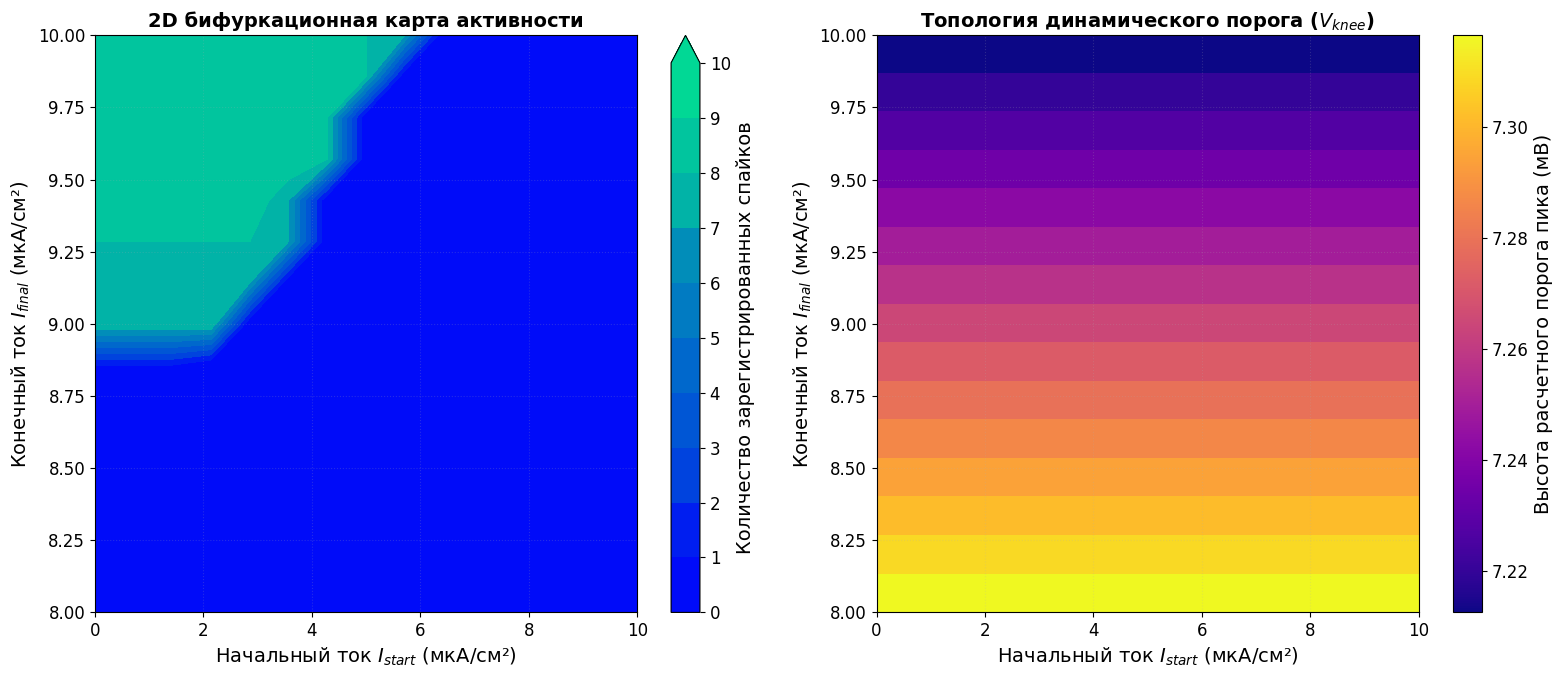

In [1]:
"""
Morris-Lecar Model: 2D Parametric Maps of Spiking Counts and Dynamic Thresholds.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.signal import find_peaks
from matplotlib.colors import LinearSegmentedColormap

# Настройка шрифтов для публикаций и репозиториев
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# Константы биологической модели Морриса-Лекара
PARAMS = {
    'C': 20.0, 'g_leak': 0.20, 'V_leak': -50.0,
    'g_Ca': 4.4, 'V_Ca': 100.0, 'g_K': 8.0, 'V_K': -70.0,
    'V1': -1.0, 'V2': 15.0, 'V3': 2.0, 'V4': 30.0, 'phi': 0.05
}

def inf_m(V):
    return 1 / (1 + np.exp((PARAMS['V1'] - V) / PARAMS['V2']))

def inf_n(V):
    return 1 / (1 + np.exp((PARAMS['V3'] - V) / PARAMS['V4']))

def V0_for_I_start(I_start):
    """Вычисление стационарного потенциала покоя для тока I_start."""
    def eq(V):
        m_inf = inf_m(V)
        n_inf = inf_n(V)
        I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
        I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
        I_K = PARAMS['g_K'] * n_inf * (V - PARAMS['V_K'])
        return (-I_leak - I_Ca - I_K + I_start) / PARAMS['C']
    return fsolve(eq, -60.0)[0]

def morris_lecar(t, y, I):
    """Правая часть базовой системы ОДУ."""
    V, n = y
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * inf_m(V) * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n * (V - PARAMS['V_K'])
    dVdt = (-I_leak - I_Ca - I_K + I) / PARAMS['C']
    dn_dt = PARAMS['phi'] * (inf_n(V) - n)
    return [dVdt, dn_dt]

def find_right_knee_V_dynamic(I_start, I_final):
    """Вычисление динамического порога (правого колена) с учетом предыстории токов."""
    def effective_n_nullcline(V):
        m_inf = inf_m(V)
        I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
        I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
        denom = PARAMS['g_K'] * (V - PARAMS['V_K'])
        if abs(denom) < 1e-10:
            return 0.0
        return np.clip((I_final - I_leak - I_Ca) / denom, 0, 1)

    def dn_dV_effective(V):
        dV = 0.1
        return (effective_n_nullcline(V + dV) - effective_n_nullcline(V - dV)) / (2 * dV)

    return fsolve(dn_dV_effective, 5.0)[0]

def generate_bifurcation_maps():
    print("Запуск сканирования двухпараметрического пространства...")
    I_start_range = np.linspace(0.0, 10.0, 15)
    I_final_range = np.linspace(8.0, 10.0, 15)

    spike_map = np.zeros((len(I_start_range), len(I_final_range)))
    knee_map = np.zeros_like(spike_map)

    t_span = [0, 1500]
    t_eval = np.linspace(0, 1500, 4000)

    for i, I_start in enumerate(I_start_range):
        for j, I_final in enumerate(I_final_range):
            V0 = V0_for_I_start(I_start)
            n0 = inf_n(V0)

            # Определение динамического порога пика
            V_peak_threshold = find_right_knee_V_dynamic(I_start, I_final)
            knee_map[i, j] = V_peak_threshold

            # Функция ступенчатого изменения тока во времени
            def input_I(t):
                return np.where(t < 100.0, I_start, I_final)

            sol = solve_ivp(
                lambda t, y: morris_lecar(t, y, input_I(t)),
                t_span, [V0, n0], t_eval=t_eval,
                method='LSODA', rtol=1e-5
            )

            # Считаем спайки только после подачи нового стимула (t > 100 мс)
            peaks, _ = find_peaks(sol.y[0][t_eval > 100.0], height=V_peak_threshold, distance=40)
            spike_map[i, j] = len(peaks)

    print(f"Расчет окончен. Максимальное число обнаруженных спайков: {np.max(spike_map):.0f}")

    # Создание кастомной цветовой палитры для карты спайков
    colors_custom = [(0/255, 11/255, 249/255), (1/255, 216/255, 149/255)]
    cmap_spikes = LinearSegmentedColormap.from_list('spike_map', colors_custom, N=12)

    # --- СТРОИМ ДВУХПАНЕЛЬНЫЙ ГРАФИК ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Сетка для контурного графика (размерность должна строго соответствовать матрице)
    I_start_grid, I_final_grid = np.meshgrid(I_start_range, I_final_range)

    # Левая панель: Карта частоты (количества спайков)
    max_spikes = int(np.max(spike_map))
    levels = np.arange(0, max_spikes + 2, 1)
    contour1 = ax1.contourf(I_start_grid, I_final_grid, spike_map.T,
                            levels=levels, cmap=cmap_spikes, extend='max')
    cbar1 = plt.colorbar(contour1, ax=ax1, ticks=levels)
    cbar1.set_label('Количество зарегистрированных спайков')
    ax1.set_xlabel('Начальный ток $I_{start}$ (мкА/см²)')
    ax1.set_ylabel('Конечный ток $I_{final}$ (мкА/см²)')
    ax1.set_title('2D бифуркационная карта активности', fontweight='bold')
    ax1.grid(True, alpha=0.2, linestyle=':')

    # Правая панель: Карта изменения динамического порога
    im2 = ax2.imshow(knee_map.T, extent=[I_start_range[0], I_start_range[-1],
                                         I_final_range[0], I_final_range[-1]],
                     origin='lower', cmap='plasma', aspect='auto')
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Высота расчетного порога пика (мВ)')
    ax2.set_xlabel('Начальный ток $I_{start}$ (мкА/см²)')
    ax2.set_ylabel('Конечный ток $I_{final}$ (мкА/см²)')
    ax2.set_title('Топология динамического порога ($V_{knee}$)', fontweight='bold')
    ax2.grid(True, alpha=0.2, linestyle=':')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_bifurcation_maps()